# Stat Chronodel

Initially, the aim was to compute sensitivity, specificity, positive predictive value, and negative predictive value for the Chronodel test. However, a low variability in outcomes was observed, with a high proportion of successful results.

Therefore, the analysis plan was revised to focus on success rates across the three tests (DOTWB, MOTYB, Chronodel) in order to assess their coherence and investigate potential ceiling effects.

In [2]:
import pandas as pd

Data = pd.read_csv("ChronodelSansTNC_DATA_2026-03-30_1433.csv")
Data.head()

,record_id,redcap_repeat_instrument,redcap_repeat_instance,redcap_survey_identifier,chronodel_sans_tnc_timestamp,mail,date_inclusion,date_evalution,num_inclusion,age_inclusion,...,chrono_arrettrente,chrono_trente,mmse,mmse_orientation,mmse_apprenti,mmsse_calcul,mmse_rappel,mmse_langage,mmse_praxies,chronodel_sans_tnc_complete
0,1,chronodel_sans_tnc,1,NaN,2026-02-05 13:57:25,valery.antoine@chu-nimes.fr,2025-12-09,2025-12-09,C03P012,92,...,NaN,NaN,20,7,3,2,0.0,7,1,2
1,1,chronodel_sans_tnc,2,NaN,2026-02-05 14:18:30,valery.antoine@chu-nimes.fr,2025-11-19,2025-11-19,C03P011,86,...,NaN,NaN,28,10,3,5,1.0,8,1,2
2,1,chronodel_sans_tnc,3,NaN,2026-02-05 14:46:53,valery.antoine@chu-nimes.fr,2025-12-17,2025-12-17,C03P010,94,...,NaN,NaN,23,8,3,5,0.0,7,0,2
3,1,chronodel_sans_tnc,4,NaN,2026-02-05 15:05:07,valery.antoine@chu-nimes.fr,2025-12-17,2025-12-17,C03P009,98,...,NaN,NaN,20,6,3,4,0.0,6,1,2
4,1,chronodel_sans_tnc,5,NaN,2026-02-05 15:17:28,valery.antoine@chu-nimes.fr,2025-12-10,2025-12-10,C03P008,85,...,NaN,NaN,25,10,3,1,3.0,7,1,2


First, the dataset was loaded and imported for analysis.

In [3]:
# Delete the lines 11, 28 and 29
Data = Data.drop([11, 28, 29])

Subjects 11, 28, and 29 were excluded from the dataset as they did not meet the study’s inclusion criteria. Subjects 11 and 28 were excluded due to hearing impairment. Subject 29 was excluded due to insufficient proficiency in French, as the test is administered in French, which may have introduced a potential bias in task comprehension.

In [4]:
# show me the number of lines
len(Data)

40

The initial sample consisted of 43 subjects. Following exclusion based on the inclusion criteria, the final sample size was reduced to 40 participants.

In [5]:
variables = ["jour_reussite", "mois_reussi", "chrono_reussi"]

for var in variables:
    print(f"\nDistribution for {var}:")
    print(Data[var].value_counts(normalize=True) * 100)
    
    print(f"Success rate for {var}: {Data[var].mean() * 100:.2f}%")


Distribution for jour_reussite:
jour_reussite
1.0    97.297297
0.0     2.702703
Name: proportion, dtype: float64
Success rate for jour_reussite: 97.30%

Distribution for mois_reussi:
mois_reussi
1.0    58.974359
0.0    41.025641
Name: proportion, dtype: float64
Success rate for mois_reussi: 58.97%

Distribution for chrono_reussi:
chrono_reussi
1    100.0
Name: proportion, dtype: float64
Success rate for chrono_reussi: 100.00%


For the first figure, the percentage of correct responses (0 = no, 1 = yes) was computed for the three tests (DOTWB, MOTYB, and Chronodel).

The DOTWB test showed a success rate of 97.29%, with 2.70% of failures. This indicates a very high performance level, with a marked ceiling effect.

The MOTYB test showed a more balanced distribution, with a success rate of 58.97% and 41.02% of failures.

Finally, the Chronodel test showed a 100% success rate, indicating no variability in the results and a strong ceiling effect.

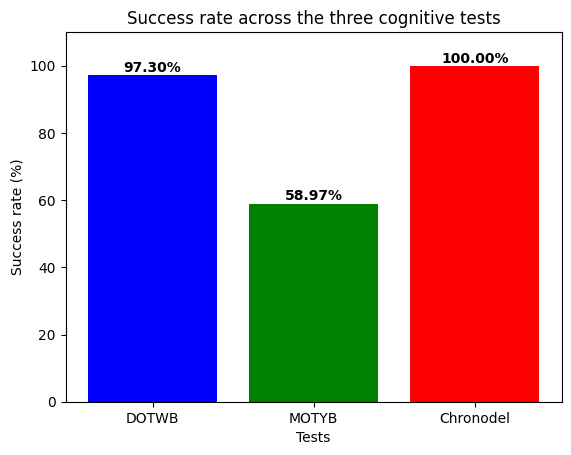

In [11]:
import matplotlib.pyplot as plt

labels = ["DOTWB", "MOTYB", "Chronodel"]

values = [
    Data["jour_reussite"].value_counts(normalize=True).reindex([0,1], fill_value=0)[1] * 100,
    Data["mois_reussi"].value_counts(normalize=True).reindex([0,1], fill_value=0)[1] * 100,
    Data["chrono_reussi"].value_counts(normalize=True).reindex([0,1], fill_value=0)[1] * 100
]

colors = ["blue", "green", "red"]

plt.bar(labels, values, color=colors)

plt.xlabel("Tests")
plt.ylabel("Success rate (%)")
plt.title("Success rate across the three cognitive tests")
plt.ylim(0, 110)

for i, v in enumerate(values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center", fontweight="bold")

plt.show()

These results suggest a pronounced ceiling effect for both the DOTWB and Chronodel tests, as evidenced by their high success rates. In contrast, the MOTYB test shows a more balanced distribution of outcomes, with a success rate closer to 50%.

In [ ]:
#create a new csv file of the data with only the columns "jour_reussite", "mois_reussi" and "chrono_reussi" with a new name "Stat_Chronodel_Rstudio_test.csv"
Data[["jour_reussite", "mois_reussi", "chrono_reussi"]].to_csv("Stat_Chronodel_Rstudio_test.csv", index=False)